# Forecasting ISO New England Peak Demand

This notebook develops a daily peak demand forecasting prototype using official ISO New England system load and archived Global Forecast System temperature forecasts retrieved through the Open Meteo Previous Runs API. Each weather value was forecast 24 hours before its valid hour.

The analysis follows the full workflow from raw data through temporal validation, 2025 evaluation, and a retrospective dispatch sensitivity test. It intentionally does not create or modify any HTML file.

## 1. Setup and data locations

Six cities provide a compact representation of weather across New England. The raw load and archived forecast files are retained unchanged in the repository.

In [1]:
from __future__ import annotations

import json
import subprocess
import urllib.parse
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.ensemble import HistGradientBoostingRegressor

ROOT = Path.cwd()
RAW_LOAD_DIR = ROOT / 'data' / 'raw' / 'isone_load'
FORECAST_PATH = ROOT / 'data' / 'raw' / 'weather' / 'new_england_hourly_gfs_day_ahead_forecast.csv'
FORECAST_ARCHIVE_START = '2021-03-23'
CV_YEARS = (2022, 2023, 2024)

CITIES = {
    'boston': (42.3601, -71.0589),
    'hartford': (41.7658, -72.6734),
    'providence': (41.8240, -71.4128),
    'concord_nh': (43.2081, -71.5376),
    'portland_me': (43.6591, -70.2568),
    'burlington_vt': (44.4759, -73.2121),
}

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. ISO New England load ingestion

ISO New England publishes annual fixed width EEI load files. Each date is stored in two records containing 12 hourly values. The parser converts them to a tidy hourly table and handles the zero used for an older daylight saving time gap.

In [2]:
def parse_eei_file(path: Path) -> pd.DataFrame:
    rows = []
    for line_number, line in enumerate(path.read_text().splitlines(), start=1):
        if not line.strip():
            continue
        if len(line) < 60:
            raise ValueError(f'{path}:{line_number}: record is too short')
        prefix = line[:-60].strip()
        period = int(prefix[-1])
        date_text = prefix[:-1]
        fmt = '%m%d%Y' if len(date_text) == 8 else '%m%d%y'
        operating_date = pd.to_datetime(date_text, format=fmt)
        values = [int(line[i:i + 5]) for i in range(len(line) - 60, len(line), 5)]
        if period not in (1, 2) or len(values) != 12:
            raise ValueError(f'{path}:{line_number}: malformed EEI record')
        first_hour = 1 if period == 1 else 13
        for offset, load_mw in enumerate(values):
            hour_ending = first_hour + offset
            rows.append({
                'operating_date': operating_date,
                'hour_ending': hour_ending,
                'timestamp_local': operating_date + pd.Timedelta(hours=hour_ending - 1),
                'load_mw': load_mw,
                'source_file': path.name,
            })
    return pd.DataFrame(rows)


def build_hourly_load(raw_dir: Path) -> pd.DataFrame:
    files = sorted(raw_dir.glob('*_eei_loads.txt'))
    if not files:
        raise FileNotFoundError(f'No ISO New England load files found in {raw_dir}')
    data = pd.concat([parse_eei_file(path) for path in files], ignore_index=True)
    data = data.sort_values('timestamp_local')
    duplicates = data.duplicated(['operating_date', 'hour_ending']).sum()
    if duplicates:
        raise ValueError(f'Found {duplicates} duplicate operating date and hour records')
    data['is_dst_gap'] = data['load_mw'].eq(0)
    data['load_mw'] = data['load_mw'].replace(0, np.nan).astype(float)
    data['load_mw'] = data.groupby('operating_date')['load_mw'].transform(
        lambda series: series.interpolate(limit_direction='both')
    )
    return data


def download_isone_load(start_year: int = 2015, end_year: int = 2026) -> None:
    """Optional refresh helper. Existing raw files are already included."""
    RAW_LOAD_DIR.mkdir(parents=True, exist_ok=True)
    base = 'https://www.iso-ne.com/static-assets/documents/'
    raise NotImplementedError(
        'ISO New England periodically changes download URLs. Use the report page to refresh files when needed: '
        'https://www.iso-ne.com/isoexpress/web/reports/load-and-demand/-/tree/sys-load-eei-fmt'
    )

hourly_load = build_hourly_load(RAW_LOAD_DIR)
print(f'Hourly load: {len(hourly_load):,} rows from {hourly_load.operating_date.min():%Y-%m-%d} to {hourly_load.operating_date.max():%Y-%m-%d}')

Hourly load: 101,520 rows from 2015-01-01 to 2026-07-31


## 3. Archived day ahead weather forecasts

The current model uses `temperature_2m_previous_day1`, which is the GFS temperature predicted 24 hours before each valid hour. Open Meteo is the retrieval service; GFS is the underlying NOAA forecast model. The download helper is only used if the retained archive is absent or incomplete.

In [3]:
def download_day_ahead_forecasts(output_path: Path, start: str, end: str) -> pd.DataFrame:
    start = max(start, FORECAST_ARCHIVE_START)
    params = {
        'latitude': ','.join(str(coords[0]) for coords in CITIES.values()),
        'longitude': ','.join(str(coords[1]) for coords in CITIES.values()),
        'start_date': start,
        'end_date': end,
        'hourly': 'temperature_2m_previous_day1',
        'models': 'gfs_seamless',
        'timezone': 'America/New_York',
    }
    url = 'https://previous-runs-api.open-meteo.com/v1/forecast?' + urllib.parse.urlencode(params)
    response = subprocess.run(
        ['curl', '--fail', '--location', '--silent', '--show-error', url],
        check=True, capture_output=True, text=True,
    )
    payload = json.loads(response.stdout)
    payloads = payload if isinstance(payload, list) else [payload]
    frames = []
    for city, city_payload in zip(CITIES, payloads):
        frame = pd.DataFrame(city_payload['hourly']).rename(columns={
            'time': 'timestamp_local',
            'temperature_2m_previous_day1': 'temperature_2m',
        })
        frame['timestamp_local'] = pd.to_datetime(frame['timestamp_local'])
        frame['city'] = city
        frames.append(frame)
    weather = pd.concat(frames, ignore_index=True)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    weather.to_csv(output_path, index=False)
    return weather


def load_or_download_forecasts(output_path: Path, start: str, end: str) -> pd.DataFrame:
    start = max(start, FORECAST_ARCHIVE_START)
    if output_path.exists():
        weather = pd.read_csv(output_path, parse_dates=['timestamp_local'])
        if weather.timestamp_local.min() <= pd.Timestamp(start) and weather.timestamp_local.max() >= pd.Timestamp(end):
            return weather
    return download_day_ahead_forecasts(output_path, start, end)

weather = load_or_download_forecasts(
    FORECAST_PATH,
    str(hourly_load.operating_date.min().date()),
    str(hourly_load.operating_date.max().date()),
)
print(f'Archived forecasts: {len(weather):,} city hours')

Archived forecasts: 281,808 city hours


## 4. Daily feature construction

The target is each day's maximum ISO New England system load. Weather features summarize the archived regional forecast. Load features are shifted before rolling calculations so no current or future load enters a forecast. Missing forecast days remain explicit calendar gaps, preventing nonadjacent days from being treated as consecutive.

In [4]:
def build_daily_dataset(load: pd.DataFrame, weather: pd.DataFrame) -> pd.DataFrame:
    daily_load = load.groupby('operating_date').agg(
        peak_load_mw=('load_mw', 'max'),
        energy_mwh=('load_mw', 'sum'),
    ).reset_index()
    peak_hours = load.loc[
        load.groupby('operating_date')['load_mw'].idxmax(),
        ['operating_date', 'hour_ending'],
    ]
    daily_load = daily_load.merge(peak_hours, on='operating_date', how='left')

    hourly_region = weather.groupby('timestamp_local').agg(
        temperature_f=('temperature_2m', lambda x: x.mean() * 9 / 5 + 32),
    ).reset_index()
    hourly_region['operating_date'] = hourly_region.timestamp_local.dt.normalize()
    daily_weather = hourly_region.groupby('operating_date').agg(
        temp_max_f=('temperature_f', 'max'),
        temp_min_f=('temperature_f', 'min'),
        temp_mean_f=('temperature_f', 'mean'),
        forecast_hour_count=('temperature_f', 'count'),
    ).reset_index()
    daily_weather = daily_weather[daily_weather.forecast_hour_count == 24].drop(columns='forecast_hour_count')

    daily = daily_load.merge(daily_weather, on='operating_date', how='left').sort_values('operating_date')
    daily['year'] = daily.operating_date.dt.year
    daily['month'] = daily.operating_date.dt.month
    daily['dayofweek'] = daily.operating_date.dt.dayofweek
    daily['dayofyear'] = daily.operating_date.dt.dayofyear
    daily['is_weekend'] = (daily.dayofweek >= 5).astype(int)
    daily['cooling_degrees'] = (daily.temp_max_f - 65).clip(lower=0)
    daily['heating_degrees'] = (55 - daily.temp_mean_f).clip(lower=0)
    daily['temp_sq'] = daily.temp_mean_f ** 2
    daily['sin_doy'] = np.sin(2 * np.pi * daily.dayofyear / 365.25)
    daily['cos_doy'] = np.cos(2 * np.pi * daily.dayofyear / 365.25)

    holiday_dates = USFederalHolidayCalendar().holidays(
        start=daily.operating_date.min(), end=daily.operating_date.max()
    )
    daily['is_holiday'] = daily.operating_date.isin(holiday_dates).astype(int)
    daily['is_business_day'] = ((daily.dayofweek < 5) & (daily.is_holiday == 0)).astype(int)
    daily['trend_days'] = (daily.operating_date - daily.operating_date.min()).dt.days

    for lag in (1, 2, 3, 7, 14, 21, 28):
        daily[f'lag_{lag}_peak_mw'] = daily.peak_load_mw.shift(lag)
    daily['rolling_7_peak_mw'] = daily.peak_load_mw.shift(1).rolling(7).mean()
    for window in (3, 14, 28):
        history = daily.peak_load_mw.shift(1).rolling(window)
        daily[f'rolling_{window}_mean_mw'] = history.mean()
        daily[f'rolling_{window}_std_mw'] = history.std()
        daily[f'rolling_{window}_max_mw'] = history.max()

    daily['weighted_temp_3d_f'] = (
        10 * daily.temp_max_f + 5 * daily.temp_max_f.shift(1) + 2 * daily.temp_max_f.shift(2)
    ) / 17
    daily['cooling_sq'] = daily.cooling_degrees ** 2
    daily['heating_sq'] = daily.heating_degrees ** 2
    return daily.dropna().reset_index(drop=True)

daily = build_daily_dataset(hourly_load, weather)
print(f'Modeling days: {len(daily):,} from {daily.operating_date.min():%Y-%m-%d} to {daily.operating_date.max():%Y-%m-%d}')
daily.head()

Modeling days: 1,930 from 2021-03-26 to 2026-07-31


,operating_date,peak_load_mw,energy_mwh,hour_ending,temp_max_f,temp_min_f,temp_mean_f,year,month,dayofweek,dayofyear,is_weekend,cooling_degrees,heating_degrees,temp_sq,sin_doy,cos_doy,is_holiday,is_business_day,trend_days,lag_1_peak_mw,lag_2_peak_mw,lag_3_peak_mw,lag_7_peak_mw,lag_14_peak_mw,lag_21_peak_mw,lag_28_peak_mw,rolling_7_peak_mw,rolling_3_mean_mw,rolling_3_std_mw,rolling_3_max_mw,rolling_14_mean_mw,rolling_14_std_mw,rolling_14_max_mw,rolling_28_mean_mw,rolling_28_std_mw,rolling_28_max_mw,weighted_temp_3d_f,cooling_sq,heating_sq
0,2021-03-26,13673.0,287366.0,11,60.59,48.32,54.99000,2021,3,4,85,0,0.0,0.01000,3023.900100,0.994110,0.108377,0,1,2276,13780.0,14029.0,13783.0,15015.0,13947.0,16694.0,15786.0,13898.428571,13864.000000,142.902064,14029.0,14595.857143,1074.274486,16966.0,15279.142857,1170.980966,17767.0,61.038235,0.0,0.000100
1,2021-03-27,12510.0,254371.0,20,54.23,41.42,47.08750,2021,3,5,86,1,0.0,7.91250,2217.232656,0.995827,0.091261,0,0,2277,13673.0,13780.0,14029.0,13332.0,14265.0,15960.0,15111.0,13706.714286,13827.333333,182.659063,14029.0,14576.285714,1089.394357,16966.0,15203.678571,1204.707404,17767.0,57.159412,0.0,62.607656
2,2021-03-28,13959.0,282184.0,18,50.42,41.78,45.95375,2021,3,6,87,1,0.0,9.04625,2111.747139,0.997250,0.074117,0,0,2278,12510.0,13673.0,13780.0,13371.0,15324.0,15903.0,15354.0,13589.285714,13321.000000,704.381289,13780.0,14450.928571,1220.995084,16966.0,15110.785714,1307.971836,17767.0,52.737059,0.0,81.834639
3,2021-03-29,14211.0,287634.0,20,48.05,35.90,41.49750,2021,3,0,88,0,0.0,13.50250,1722.042506,0.998377,0.056952,0,1,2279,13959.0,12510.0,13673.0,13979.0,16966.0,16417.0,16504.0,13673.285714,13380.666667,767.459662,13959.0,14353.428571,1200.238099,16966.0,15060.964286,1324.824167,17767.0,49.474118,0.0,182.317506
4,2021-03-30,13865.0,288071.0,20,56.33,32.87,44.22875,2021,3,1,89,0,0.0,10.77125,1956.182327,0.999209,0.039770,0,1,2280,14211.0,13959.0,12510.0,13783.0,16077.0,15223.0,17767.0,13706.428571,13560.000000,918.014706,14211.0,14156.642857,935.621604,16077.0,14979.071429,1303.010785,17767.0,53.199412,0.0,116.019827


## 5. Models and evaluation metrics

Ridge regression provides a stable linear benchmark. Histogram gradient boosting captures nonlinear relationships. The final ensemble blends 75 percent gradient boosting with 25 percent Ridge. Mean absolute error and root mean squared error evaluate all days, while top five recall measures identification of the highest demand days.

In [5]:
EXCLUDED_COLUMNS = {'operating_date', 'peak_load_mw', 'energy_mwh', 'hour_ending', 'year', 'dayofyear'}

def feature_columns(frame: pd.DataFrame) -> list[str]:
    return [column for column in frame.columns if column not in EXCLUDED_COLUMNS]

def design_matrix(frame: pd.DataFrame, columns: list[str] | None = None) -> pd.DataFrame:
    return frame[columns or feature_columns(frame)].astype(float).copy()

@dataclass
class RidgePeakModel:
    alpha: float
    columns: list[str] | None = None
    means: np.ndarray | None = None
    scales: np.ndarray | None = None
    coefficients: np.ndarray | None = None
    intercept: float = 0.0

    def fit(self, frame: pd.DataFrame, target: pd.Series):
        self.columns = feature_columns(frame)
        x = design_matrix(frame, self.columns).to_numpy(float)
        self.means = x.mean(axis=0)
        self.scales = x.std(axis=0)
        self.scales[self.scales == 0] = 1
        z = (x - self.means) / self.scales
        y = target.to_numpy(float)
        self.intercept = float(y.mean())
        penalty = self.alpha * np.eye(z.shape[1])
        self.coefficients = np.linalg.solve(z.T @ z + penalty, z.T @ (y - self.intercept))
        return self

    def predict(self, frame: pd.DataFrame) -> np.ndarray:
        x = design_matrix(frame, self.columns).to_numpy(float)
        return self.intercept + ((x - self.means) / self.scales) @ self.coefficients

@dataclass
class HGBPeakModel:
    max_leaf_nodes: int
    columns: list[str] | None = None
    estimator: HistGradientBoostingRegressor | None = None

    def fit(self, frame: pd.DataFrame, target: pd.Series):
        self.columns = feature_columns(frame)
        self.estimator = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_leaf_nodes=self.max_leaf_nodes,
            min_samples_leaf=20, l2_regularization=10, random_state=42,
        )
        self.estimator.fit(design_matrix(frame, self.columns), target)
        return self

    def predict(self, frame: pd.DataFrame) -> np.ndarray:
        return self.estimator.predict(design_matrix(frame, self.columns))

@dataclass
class EnsemblePeakModel:
    hgb_weight: float = 0.75
    hgb: HGBPeakModel | None = None
    ridge: RidgePeakModel | None = None

    def fit(self, frame: pd.DataFrame, target: pd.Series):
        self.hgb = HGBPeakModel(15).fit(frame, target)
        self.ridge = RidgePeakModel(10.0).fit(frame, target)
        return self

    def predict(self, frame: pd.DataFrame) -> np.ndarray:
        return self.hgb_weight * self.hgb.predict(frame) + (1 - self.hgb_weight) * self.ridge.predict(frame)

def score_predictions(frame: pd.DataFrame, predicted: np.ndarray) -> dict:
    actual = frame.peak_load_mw.to_numpy()
    scored = frame.assign(_prediction=predicted)
    actual_top = set(scored.nlargest(5, 'peak_load_mw').index)
    predicted_top = set(scored.nlargest(5, '_prediction').index)
    return {
        'mae_mw': float(np.abs(actual - predicted).mean()),
        'rmse_mw': float(np.sqrt(np.square(actual - predicted).mean())),
        'top5_recall': len(actual_top & predicted_top) / 5,
    }

## 6. Expanding window validation and 2025 test

For each validation year, training uses only earlier years. Model selection is based on average validation error across 2022, 2023, and 2024. The selected model is fitted through 2024 and evaluated on the 2025 retrospective test period.

In [6]:
CANDIDATES: list[tuple[str, Callable[[], object] | None]] = [
    ('seven_day_baseline', None),
    ('ridge_10', lambda: RidgePeakModel(10.0)),
    ('hgb_7_leaf', lambda: HGBPeakModel(7)),
    ('hgb_15_leaf', lambda: HGBPeakModel(15)),
    ('ensemble_hgb75_ridge25', lambda: EnsemblePeakModel()),
]

def rolling_origin_score(model_name: str, factory: Callable[[], object] | None) -> dict:
    folds = []
    for year in CV_YEARS:
        train = daily[daily.year < year]
        validation = daily[daily.year == year]
        prediction = (
            validation.lag_7_peak_mw.to_numpy()
            if factory is None
            else factory().fit(train, train.peak_load_mw).predict(validation)
        )
        folds.append(score_predictions(validation, prediction))
    fold_frame = pd.DataFrame(folds)
    return {
        'model': model_name,
        'split': 'rolling_cv_2022_2024',
        'mae_mw': fold_frame.mae_mw.mean(),
        'rmse_mw': fold_frame.rmse_mw.mean(),
        'top5_recall': fold_frame.top5_recall.mean(),
    }

cv_metrics = pd.DataFrame([rolling_origin_score(name, factory) for name, factory in CANDIDATES])
eligible = cv_metrics[cv_metrics.model != 'seven_day_baseline']
best_name = eligible.sort_values(['mae_mw', 'rmse_mw']).iloc[0].model
best_factory = dict(CANDIDATES)[best_name]

train_final = daily[daily.year <= 2024]
test = daily[daily.year == 2025].copy()
final_model = best_factory().fit(train_final, train_final.peak_load_mw)
test['predicted_peak_mw'] = final_model.predict(test)
test_metrics = {'model': best_name, 'split': 'retrospective_test_2025', **score_predictions(test, test.predicted_peak_mw.to_numpy())}
metrics = pd.concat([cv_metrics, pd.DataFrame([test_metrics])], ignore_index=True)

display(metrics.assign(
    mae_mw=lambda x: x.mae_mw.round(0).astype(int),
    rmse_mw=lambda x: x.rmse_mw.round(0).astype(int),
    top5_recall=lambda x: (100 * x.top5_recall).round(0).astype(int).astype(str) + '%',
))

selected_validation = cv_metrics.loc[cv_metrics.model == best_name].iloc[0]
print(f'2022 through 2024 expanding-window validation MAE: {selected_validation.mae_mw:.0f} MW')
print(f'2025 retrospective daily peak MAE: {test_metrics["mae_mw"]:.0f} MW')

,model,split,mae_mw,rmse_mw,top5_recall
0,seven_day_baseline,rolling_cv_2022_2024,1411,2082,0%
1,ridge_10,rolling_cv_2022_2024,552,712,73%
2,hgb_7_leaf,rolling_cv_2022_2024,503,699,73%
3,hgb_15_leaf,rolling_cv_2022_2024,499,697,80%
4,ensemble_hgb75_ridge25,rolling_cv_2022_2024,460,634,73%
5,ensemble_hgb75_ridge25,retrospective_test_2025,421,610,80%


2022 through 2024 expanding-window validation MAE: 460 MW
2025 retrospective daily peak MAE: 421 MW


## 7. Actual and predicted daily peak load

The time series view shows how the selected model follows seasonal and daily demand patterns during 2025.

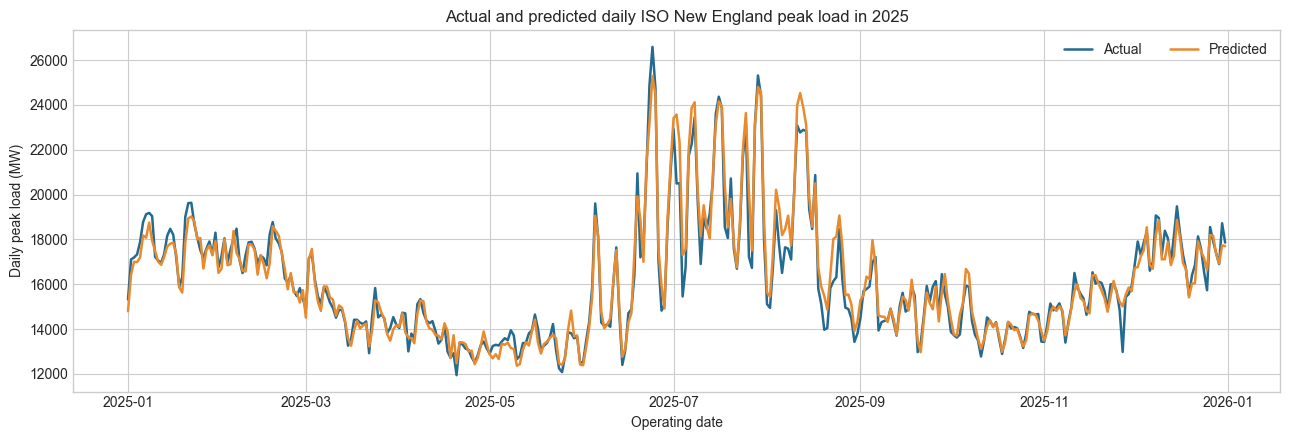

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(test.operating_date, test.peak_load_mw, label='Actual', color='#246b91', linewidth=1.8)
ax.plot(test.operating_date, test.predicted_peak_mw, label='Predicted', color='#e98a2e', linewidth=1.8)
ax.set(title='Actual and predicted daily ISO New England peak load in 2025', xlabel='Operating date', ylabel='Daily peak load (MW)')
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

## 8. Retrospective dispatch sensitivity

For each completed month, days are ranked by predicted peak. This test asks whether the actual monthly peak falls among the highest one, two, or three forecasts. It measures ranking ability, not a live dispatch policy.

,dispatches_per_month,monthly_peaks_captured
0,1,8
1,2,12
2,3,12


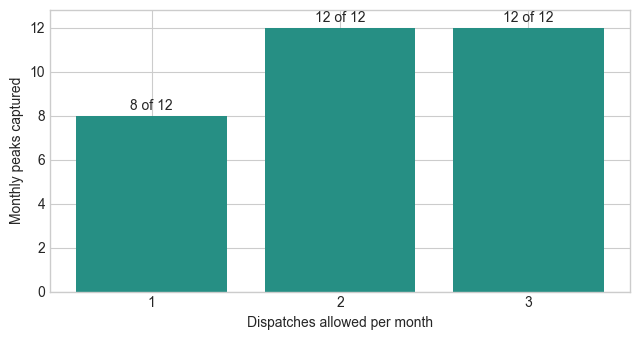

In [8]:
def monthly_peak_capture(predictions: pd.DataFrame, selections: int) -> int:
    frame = predictions.copy()
    frame['month_period'] = frame.operating_date.dt.to_period('M')
    captured = 0
    for _, group in frame.groupby('month_period'):
        actual_peak = group.nlargest(1, 'peak_load_mw').index[0]
        selected = set(group.nlargest(selections, 'predicted_peak_mw').index)
        captured += int(actual_peak in selected)
    return captured

capture = pd.DataFrame({
    'dispatches_per_month': [1, 2, 3],
    'monthly_peaks_captured': [monthly_peak_capture(test, k) for k in (1, 2, 3)],
})
display(capture)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(capture.dispatches_per_month.astype(str), capture.monthly_peaks_captured, color='#268f84')
ax.set(xlabel='Dispatches allowed per month', ylabel='Monthly peaks captured', ylim=(0, 12.8))
for i, value in enumerate(capture.monthly_peaks_captured):
    ax.text(i, value + 0.25, f'{value} of 12', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Interpretation and next steps

The model predicts total ISO New England system demand rather than the load of a specific municipal utility. It forecasts daily peak magnitude and likely peak days, but not the intraday peak hour. The dispatch sensitivity test ranks forecasts after each month is complete and does not account for operating costs, charging time, state of charge, degradation, outages, or cycle limits.

A live implementation could estimate tomorrow's peak each day, compare it with demand already observed during the month and a dynamic dispatch threshold, and schedule a discharge when the forecast is sufficiently high and the battery is available. Future work could add archived humidity, dew point, and apparent temperature forecasts, predict the intraday peak hour, quantify forecast uncertainty, incorporate utility load, and simulate operational battery constraints.